# Freelance Jobs — EDA & Data Cleaning Project

### Project Objective
This notebook performs a complete **Exploratory Data Analysis (EDA)** and **Data Cleaning** workflow on a deliberately dirty freelance jobs dataset.

The workflow covers:

- Dataset inspection and structure
- Missing values and NULL-like values
- Duplicate records
- Data type validation
- Date quality checks
- Numeric outlier detection
- Text quality checks
- Data cleaning and validation
- Exporting the cleaned dataset
- Final visualizations and business insights

> **Important:** The dirty dataset was created by appending corrupted copies of original records.  
> Therefore, the original clean version can be recovered safely by keeping the **first occurrence of each `Job_ID`**.

## 1. Import Libraries

We start by importing the Python libraries required for data manipulation, analysis, and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 2. Load the Dirty Dataset

The dataset is loaded from the Excel file.  
We use the `freelance_jobs` worksheet as the main analysis table.

In [5]:
INPUT_FILE = "freelance_jobs_for_EDA.xlsx"
SHEET_NAME = "freelance_jobs"
OUTPUT_FILE = "freelance_jobs_cleaned.xlsx"

df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (110850, 17)


## 3. Initial Data Inspection

Before cleaning, we inspect the structure of the data, column names, data types, and sample records.

In [6]:
display(df.head())

,Job_ID,Platform_ID,Job_Title,Job_Description,Category_ID,Client_Country_ID,Posted_Date,Budget_Type,Budget_Min,Budget_Max,Hourly_Rate,Experience_Level,Project_Duration,Applicants_Count,Proposals_Count,Hire_Rate,Job_Status
0,1,12,Full Stack Developer,We are looking for a Full Stack Developer to d...,1,31,2025-09-15 00:00:00,Hourly,23.89,33.22,31.46,Advanced,6 Months,26.00,12.00,0.58,Open
1,2,7,Senior Full Stack Developer,We are looking for a Senior Full Stack Develop...,1,40,2025-03-15 00:00:00,Fixed Price,"2,332.91","3,065.23",NaN,Advanced,3 Weeks,37.00,14.00,0.20,Completed
2,3,3,Full Stack Developer,We are looking for a Full Stack Developer to c...,1,13,2025-11-28 00:00:00,Hourly,17.82,27.77,27.58,Advanced,9 Months,36.00,19.00,0.43,Completed
3,4,3,Full Stack Developer,We are looking for a Full Stack Developer to o...,1,25,2025-11-11 00:00:00,Hourly,10.15,14.24,10.19,Advanced,12 Months,42.00,21.00,0.56,Completed
4,5,2,Full Stack Web Developer,We are looking for a Full Stack Web Developer ...,1,1,2024-11-05 00:00:00,Hourly,3.49,5.06,3.98,Entry Level,3 Months,46.00,23.00,0.53,Completed


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
for col in df.columns:
    print("-", col)

Rows: 110850
Columns: 17

Column Names:
- Job_ID
- Platform_ID
- Job_Title
- Job_Description
- Category_ID
- Client_Country_ID
- Posted_Date
- Budget_Type
- Budget_Min
- Budget_Max
- Hourly_Rate
- Experience_Level
- Project_Duration
- Applicants_Count
- Proposals_Count
- Hire_Rate
- Job_Status


In [8]:
print("Data Types:")
display(df.dtypes.to_frame("Data Type"))

Data Types:


,Data Type
Job_ID,int64
Platform_ID,int64
Job_Title,str
Job_Description,str
Category_ID,int64
Client_Country_ID,int64
Posted_Date,object
Budget_Type,str
Budget_Min,object
Budget_Max,object


In [9]:
print("General Dataset Information:")
df.info()

General Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 110850 entries, 0 to 110849
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Job_ID             110850 non-null  int64  
 1   Platform_ID        110850 non-null  int64  
 2   Job_Title          110839 non-null  str    
 3   Job_Description    107535 non-null  str    
 4   Category_ID        110850 non-null  int64  
 5   Client_Country_ID  110850 non-null  int64  
 6   Posted_Date        110838 non-null  object 
 7   Budget_Type        110850 non-null  str    
 8   Budget_Min         108586 non-null  object 
 9   Budget_Max         108585 non-null  object 
 10  Hourly_Rate        64971 non-null   object 
 11  Experience_Level   110833 non-null  str    
 12  Project_Duration   110832 non-null  str    
 13  Applicants_Count   110837 non-null  float64
 14  Proposals_Count    110837 non-null  float64
 15  Hire_Rate          110837 non-nul

## 4. Statistical Summary

We inspect descriptive statistics for numeric columns to identify unusual ranges, possible outliers, and invalid values.

In [10]:
display(df.describe(include="number").T)

,count,mean,std,min,25%,50%,75%,max
Job_ID,"110,850.00","55,126.16","31,998.64",1.00,"27,413.25","55,125.50","82,837.75","110,550.00"
Platform_ID,"110,850.00",4.90,3.36,1.00,2.00,4.00,7.00,12.00
Category_ID,"110,850.00",6.58,4.53,1.00,2.00,6.00,10.00,17.00
Client_Country_ID,"110,850.00",20.20,14.50,1.00,7.00,19.00,32.00,55.00
Applicants_Count,"110,837.00",51.07,"2,374.30",2.00,20.00,27.00,35.00,"250,000.00"
Proposals_Count,"110,837.00",17.26,9.78,-500.00,11.00,16.00,22.00,70.00
Hire_Rate,"110,837.00",0.37,0.14,0.04,0.28,0.36,0.45,7.50


## 5. Missing Values & NULL-like Values

Dirty datasets may contain both real missing values (`NaN`) and text values such as:

`NULL`, `N/A`, `NA`, `None`, `-`

We count both types separately before cleaning.

In [11]:
null_tokens = ["NULL", "null", "N/A", "NA", "None", "-", ""]

null_like_count = pd.Series(0, index=df.columns, dtype="int64")

for col in df.columns:
    if df[col].dtype == "object":
        cleaned_text = df[col].astype("string").str.strip()
        null_like_count[col] = cleaned_text.isin(null_tokens).sum()

missing_report = pd.DataFrame({
    "Missing_NaN": df.isna().sum(),
    "NULL_Like_Text": null_like_count
})

missing_report["Total_Missing"] = (
    missing_report["Missing_NaN"] +
    missing_report["NULL_Like_Text"]
)

missing_report["Missing_%"] = (
    missing_report["Total_Missing"] / len(df) * 100
).round(2)

display(
    missing_report
    .sort_values("Total_Missing", ascending=False)
)

,Missing_NaN,NULL_Like_Text,Total_Missing,Missing_%
Hourly_Rate,45879,1,45880,41.39
Job_Description,3315,0,3315,2.99
Budget_Max,2265,1,2266,2.04
Budget_Min,2264,1,2265,2.04
Job_Status,18,0,18,0.02
Project_Duration,18,0,18,0.02
Experience_Level,17,0,17,0.02
Proposals_Count,13,0,13,0.01
Applicants_Count,13,0,13,0.01
Hire_Rate,13,0,13,0.01


### Missing Values Visualization

This chart shows which columns contain the highest number of missing or NULL-like values before cleaning.

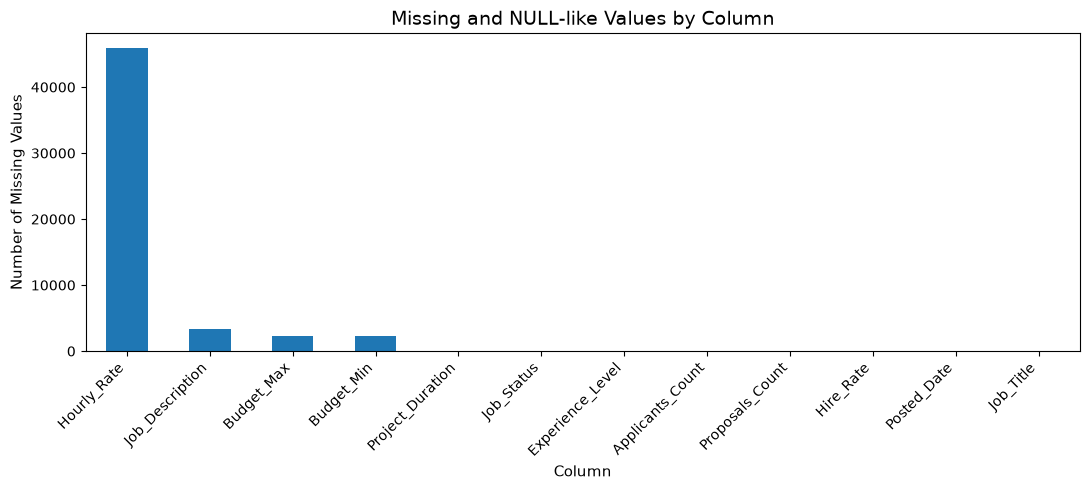

In [12]:
missing_plot = (
    missing_report["Total_Missing"]
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

if not missing_plot.empty:
    plt.figure(figsize=(11, 5))
    missing_plot.plot(kind="bar")
    plt.title("Missing and NULL-like Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

## 6. Duplicate Analysis

Duplicate records can distort totals, averages, and business metrics.

We check:

1. Exact duplicated rows.
2. Repeated `Job_ID` values.
3. Extra records caused by duplicated IDs.

In [13]:
exact_duplicates = df.duplicated().sum()
duplicated_ids_all = df.duplicated(subset=["Job_ID"], keep=False).sum()
extra_duplicated_ids = df.duplicated(subset=["Job_ID"], keep="first").sum()

print("Exact duplicated rows:", exact_duplicates)
print("Rows involved in duplicated Job_IDs:", duplicated_ids_all)
print("Extra duplicated Job_ID records:", extra_duplicated_ids)

Exact duplicated rows: 81
Rows involved in duplicated Job_IDs: 520
Extra duplicated Job_ID records: 300


In [14]:
duplicate_examples = (
    df[df.duplicated(subset=["Job_ID"], keep=False)]
    .sort_values("Job_ID")
    .head(20)
)

display(duplicate_examples)

,Job_ID,Platform_ID,Job_Title,Job_Description,Category_ID,Client_Country_ID,Posted_Date,Budget_Type,Budget_Min,Budget_Max,Hourly_Rate,Experience_Level,Project_Duration,Applicants_Count,Proposals_Count,Hire_Rate,Job_Status
0,1,12,Full Stack Developer,We are looking for a Full Stack Developer to d...,1,31,2025-09-15 00:00:00,Hourly,23.89,33.22,31.46,Advanced,6 Months,26.00,12.00,0.58,Open
110780,1,12,Full Stack Developer,We are looking for a Full Stack Developer to d...,1,31,15/09/2025,Hourly,23.89,33.22,31.46,Advanced,6 Months,26.00,12.00,0.58,Open
110550,1,12,Full Stack Developer,We are looking for a Full Stack Developer to d...,1,31,2025-09-15 00:00:00,Hourly,23.89,33.22,31.46,Advanced,6 Months,26.00,12.00,0.58,Open
1,2,7,Senior Full Stack Developer,We are looking for a Senior Full Stack Develop...,1,40,2025-03-15 00:00:00,Fixed Price,"2,332.91","3,065.23",NaN,Advanced,3 Weeks,37.00,14.00,0.20,Completed
110781,2,7,Senior Full Stack Developer,We are looking for a Senior Full Stack Develop...,1,40,09-15-2025,Fixed Price,"2,332.91","3,065.23",NaN,Advanced,3 Weeks,37.00,14.00,0.20,Completed
110551,2,7,Senior Full Stack Developer,We are looking for a Senior Full Stack Develop...,1,40,2025-03-15 00:00:00,Fixed Price,"2,332.91","3,065.23",NaN,Advanced,3 Weeks,37.00,14.00,0.20,Completed
2,3,3,Full Stack Developer,We are looking for a Full Stack Developer to c...,1,13,2025-11-28 00:00:00,Hourly,17.82,27.77,27.58,Advanced,9 Months,36.00,19.00,0.43,Completed
110782,3,3,Full Stack Developer,We are looking for a Full Stack Developer to c...,1,13,2025/09/15,Hourly,17.82,27.77,27.58,Advanced,9 Months,36.00,19.00,0.43,Completed
110552,3,3,Full Stack Developer,We are looking for a Full Stack Developer to c...,1,13,2025-11-28 00:00:00,Hourly,17.82,27.77,27.58,Advanced,9 Months,36.00,19.00,0.43,Completed
110553,4,3,Full Stack Developer,We are looking for a Full Stack Developer to o...,1,25,2025-11-11 00:00:00,Hourly,10.15,14.24,10.19,Advanced,12 Months,42.00,21.00,0.56,Completed


## 7. Date Quality Analysis

The `Posted_Date` column may contain:

- Valid Excel dates
- Different date formats
- Invalid dates
- Text instead of dates
- Unreasonable future dates

We attempt to parse all values and identify invalid records.

In [15]:
date_raw = df["Posted_Date"].copy()
date_parsed = pd.to_datetime(date_raw, errors="coerce")

invalid_date_mask = date_raw.notna() & date_parsed.isna()

print("Invalid / unparseable dates:", invalid_date_mask.sum())

if date_parsed.notna().any():
    print("Minimum parsed date:", date_parsed.min())
    print("Maximum parsed date:", date_parsed.max())

Invalid / unparseable dates: 9
Minimum parsed date: 2024-08-11 00:00:00
Maximum parsed date: 2099-01-01 00:00:00


In [16]:
display(
    df.loc[invalid_date_mask, ["Job_ID", "Posted_Date"]].head(20)
)

,Job_ID,Posted_Date
110786,7,2025-13-40
110787,8,not a date
110788,9,31/02/2025
110796,17,2025-13-40
110797,18,not a date
110798,19,31/02/2025
110806,27,2025-13-40
110807,28,not a date
110808,29,31/02/2025


## 8. Numeric Outlier Detection

We use the **IQR Method** to flag unusually high or low values.

For each numeric business field:

- `Q1` = 25th percentile
- `Q3` = 75th percentile
- `IQR = Q3 - Q1`
- Lower Bound = `Q1 - 1.5 × IQR`
- Upper Bound = `Q3 + 1.5 × IQR`

Values outside these bounds are flagged as potential outliers.

In [17]:
numeric_cols = [
    "Budget_Min",
    "Budget_Max",
    "Hourly_Rate",
    "Applicants_Count",
    "Proposals_Count",
    "Hire_Rate"
]

outlier_report = []

for col in numeric_cols:
    values = pd.to_numeric(df[col], errors="coerce")

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (values < lower) | (values > upper)

    outlier_report.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(mask.sum())
    })

outlier_report = pd.DataFrame(outlier_report)
display(outlier_report)

,Column,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,Budget_Min,7.33,"1,011.85","-1,499.45","2,518.63",17170
1,Budget_Max,10.01,"1,588.26","-2,357.36","3,955.64",17318
2,Hourly_Rate,5.34,14.77,-8.80,28.91,3737
3,Applicants_Count,20.00,35.00,-2.50,57.50,1584
4,Proposals_Count,11.00,22.00,-5.50,38.50,2543
5,Hire_Rate,0.28,0.45,0.03,0.70,622


## 9. Text Quality Checks

Text fields often require cleaning because of:

- Leading/trailing spaces
- Inconsistent capitalization
- NULL-like text values
- Category labels with accidental spaces

We inspect the most important categorical columns.

In [18]:
categorical_cols = [
    "Budget_Type",
    "Experience_Level",
    "Project_Duration",
    "Job_Status"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].astype("string").value_counts(dropna=False).head(15))


--- Budget_Type ---
Budget_Type
Hourly         56820
Fixed Price    54020
 hourly           10
Name: count, dtype: Int64

--- Experience_Level ---
Experience_Level
Intermediate    39907
Advanced        33210
Entry Level     24436
Expert          13269
<NA>               17
advanced           10
-                   1
Name: count, dtype: Int64

--- Project_Duration ---
Project_Duration
3 Months     14596
2 Months     14198
1 Month      12735
6 Months     10894
2 Weeks       9891
1 Week        8886
3 Weeks       8557
9 Months      7105
12 Months     5459
5 Days        5328
3 Days        5004
2 Days        4358
1 Day         3821
<NA>            18
Name: count, dtype: Int64

--- Job_Status ---
Job_Status
Completed      68806
Open           19934
In Progress    13229
Cancelled       8853
<NA>              18
completed         10
Name: count, dtype: Int64


# 10. Data Cleaning

Now we clean the data systematically.

### Cleaning Strategy

1. Convert textual NULL tokens into real missing values.
2. Remove dirty duplicate copies using `Job_ID`.
3. Strip unnecessary spaces from text fields.
4. Convert numeric columns to numeric types.
5. Handle remaining missing values using business rules and median imputation.
6. Parse dates correctly.
7. Sort records by `Job_ID`.

In [19]:
clean = df.copy()

### 10.1 Convert NULL-like Text to Real Missing Values

In [20]:
object_cols = clean.select_dtypes(include="object").columns

for col in object_cols:
    clean[col] = clean[col].astype("string").str.strip()

    clean[col] = clean[col].replace({
        "NULL": pd.NA,
        "null": pd.NA,
        "N/A": pd.NA,
        "NA": pd.NA,
        "None": pd.NA,
        "-": pd.NA,
        "": pd.NA
    })

C:\Users\A-FF-L4-D10\AppData\Local\Temp\ipykernel_26280\2372106780.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = clean.select_dtypes(include="object").columns


### 10.2 Remove Dirty Duplicate Copies

Because the dirty records were appended **after** the original records, the first occurrence of each `Job_ID` is the clean/original record.

In [21]:
rows_before = len(clean)

clean = clean.drop_duplicates(
    subset=["Job_ID"],
    keep="first"
).copy()

rows_after = len(clean)

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before: 110850
Rows after : 110550
Rows removed: 300


### 10.3 Clean Text Columns

In [22]:
text_cols = [
    "Job_Title",
    "Job_Description",
    "Budget_Type",
    "Experience_Level",
    "Project_Duration",
    "Job_Status"
]

for col in text_cols:
    if col in clean.columns:
        clean[col] = clean[col].astype("string").str.strip()

### 10.4 Convert Numeric Columns

In [23]:
numeric_cols_all = [
    "Job_ID",
    "Platform_ID",
    "Category_ID",
    "Client_Country_ID",
    "Budget_Min",
    "Budget_Max",
    "Hourly_Rate",
    "Applicants_Count",
    "Proposals_Count",
    "Hire_Rate"
]

for col in numeric_cols_all:
    clean[col] = pd.to_numeric(
        clean[col],
        errors="coerce"
    )

### 10.5 Handle Missing Values

After converting the relevant columns to numeric types, we handle the remaining missing values using practical business rules:

- Missing `Job_Description` values are replaced with **"No Description Provided"**.
- Missing `Budget_Min` and `Budget_Max` values are replaced with **0**.
- For **Fixed Price** jobs, a missing `Hourly_Rate` is replaced with **0** because hourly payment does not apply.
- For **Hourly** jobs, a missing `Hourly_Rate` is replaced with the **median hourly rate for the same `Experience_Level`**.

The median is preferred because it is less sensitive to extreme values than the mean.

In [24]:
# 1. Replace missing job descriptions
clean["Job_Description"] = clean["Job_Description"].fillna(
    "No Description Provided"
)

# 2. Replace missing budget values with 0
clean["Budget_Min"] = clean["Budget_Min"].fillna(0)
clean["Budget_Max"] = clean["Budget_Max"].fillna(0)

# 3. Handle missing Hourly_Rate based on Budget_Type

# Fixed Price jobs: Hourly_Rate does not apply
fixed_price_mask = clean["Budget_Type"].eq("Fixed Price")

clean.loc[fixed_price_mask, "Hourly_Rate"] = (
    clean.loc[fixed_price_mask, "Hourly_Rate"]
    .fillna(0)
)

# Hourly jobs: use the median Hourly_Rate for the same Experience_Level
hourly_mask = clean["Budget_Type"].eq("Hourly")

clean.loc[hourly_mask, "Hourly_Rate"] = (
    clean.loc[hourly_mask]
    .groupby("Experience_Level")["Hourly_Rate"]
    .transform(lambda x: x.fillna(x.median()))
)

# Fallback for any Hourly group that had no valid value to calculate a median
overall_hourly_median = clean.loc[hourly_mask, "Hourly_Rate"].median()

clean.loc[
    hourly_mask & clean["Hourly_Rate"].isna(),
    "Hourly_Rate"
] = overall_hourly_median

print("Missing values after treatment:")
print(
    clean[
        ["Job_Description", "Budget_Min", "Budget_Max", "Hourly_Rate"]
    ]
    .isna()
    .sum()
)

Missing values after treatment:
Job_Description    0
Budget_Min         0
Budget_Max         0
Hourly_Rate        0
dtype: int64


### 10.6 Convert Posted Date to Datetime

In [25]:
clean["Posted_Date"] = pd.to_datetime(
    clean["Posted_Date"],
    errors="coerce"
)

### 10.7 Sort and Reset Index

In [26]:
clean = (
    clean
    .sort_values("Job_ID")
    .reset_index(drop=True)
)

# 11. Validation After Cleaning

A good cleaning workflow should always verify the output.

We check:

- Final shape
- Unique `Job_ID`
- Remaining duplicates
- Missing values
- Data types
- Numeric ranges

In [27]:
print("Final Shape:", clean.shape)
print("Unique Job_ID:", clean["Job_ID"].is_unique)
print("Duplicate Job_ID:", clean.duplicated(subset=["Job_ID"]).sum())

Final Shape: (110550, 17)
Unique Job_ID: True
Duplicate Job_ID: 0


In [28]:
after_missing = clean.isna().sum().sort_values(ascending=False)
display(after_missing.to_frame("Missing_After_Cleaning"))

,Missing_After_Cleaning
Job_ID,0
Platform_ID,0
Job_Title,0
Job_Description,0
Category_ID,0
Client_Country_ID,0
Posted_Date,0
Budget_Type,0
Budget_Min,0
Budget_Max,0


In [29]:
display(clean.dtypes.to_frame("Clean_Data_Type"))

,Clean_Data_Type
Job_ID,int64
Platform_ID,int64
Job_Title,string
Job_Description,string
Category_ID,int64
Client_Country_ID,int64
Posted_Date,datetime64[us]
Budget_Type,string
Budget_Min,Float64
Budget_Max,Float64


In [30]:
display(clean[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Budget_Min,"110,550.00","1,590.59","4,467.22",0.00,6.91,24.35,960.52,"110,431.87"
Budget_Max,"110,550.00","2,546.68","7,248.58",0.00,9.46,33.84,"1,504.21","214,800.87"
Hourly_Rate,"110,550.00",6.93,10.19,0.00,0.00,4.03,10.25,423.12
Applicants_Count,"110,550.00",28.49,11.06,2.00,20.00,27.00,35.00,86.00
Proposals_Count,"110,550.00",17.28,8.44,1.00,11.00,16.00,22.00,70.00
Hire_Rate,"110,550.00",0.37,0.12,0.04,0.28,0.36,0.45,0.95


### Expected Recovery Check

For this practice dataset, the clean/original `freelance_jobs` table contains **110,550 records**.

If the cleaning process is correct, the final row count should match this value.

In [31]:
EXPECTED_ROWS = 110550

print("Expected rows:", EXPECTED_ROWS)
print("Actual rows  :", len(clean))
print("Match        :", len(clean) == EXPECTED_ROWS)

Expected rows: 110550
Actual rows  : 110550
Match        : True


# 12. Export Cleaned Dataset

The cleaned dataset is exported to Excel so it can later be used in:

- Power BI
- Tableau
- SQL
- Google Looker Studio
- Further Python analysis

In [32]:
clean.to_excel(
    OUTPUT_FILE,
    index=False,
    sheet_name="freelance_jobs"
)

print("Clean dataset saved as:", OUTPUT_FILE)

Clean dataset saved as: freelance_jobs_cleaned.xlsx


# 13. Final Visualizations

The following visualizations are created **after cleaning** so the analysis is based on reliable data.

These charts can also help you decide which visuals to reproduce later in Power BI.

## 13.1 Budget Type Distribution

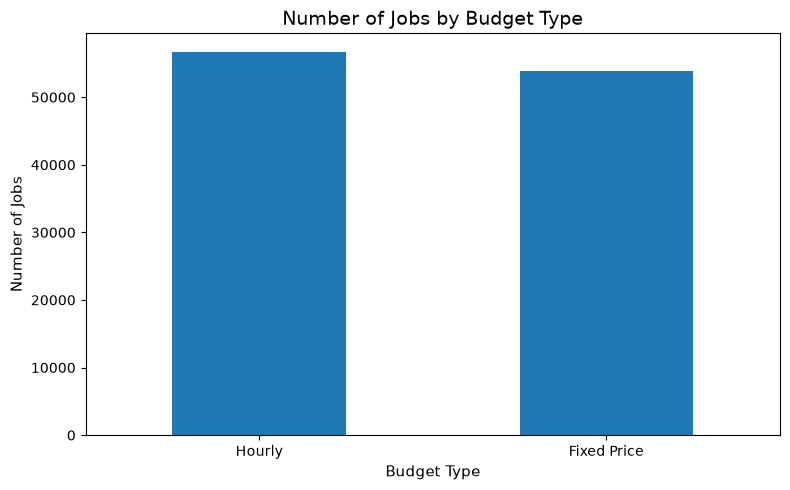

In [33]:
budget_type_counts = (
    clean["Budget_Type"]
    .value_counts()
)

plt.figure(figsize=(8, 5))
budget_type_counts.plot(kind="bar")
plt.title("Number of Jobs by Budget Type")
plt.xlabel("Budget Type")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13.2 Experience Level Distribution

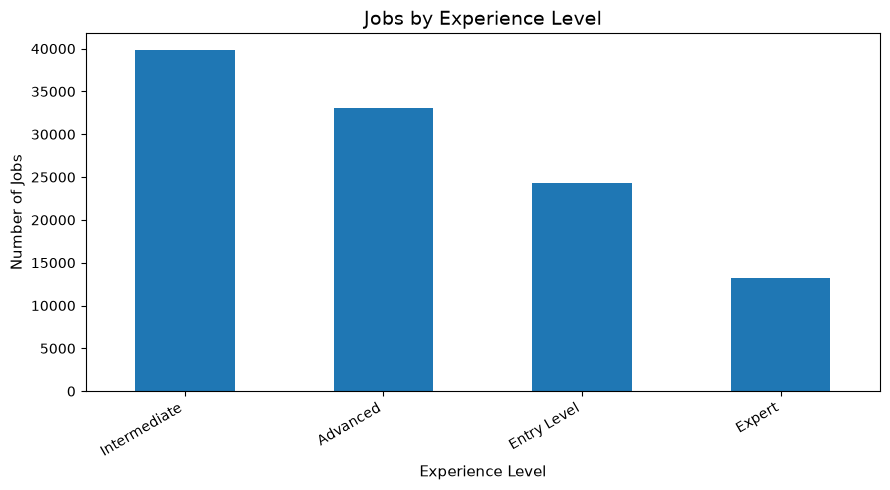

In [34]:
experience_counts = (
    clean["Experience_Level"]
    .value_counts()
)

plt.figure(figsize=(9, 5))
experience_counts.plot(kind="bar")
plt.title("Jobs by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 13.3 Job Status Distribution

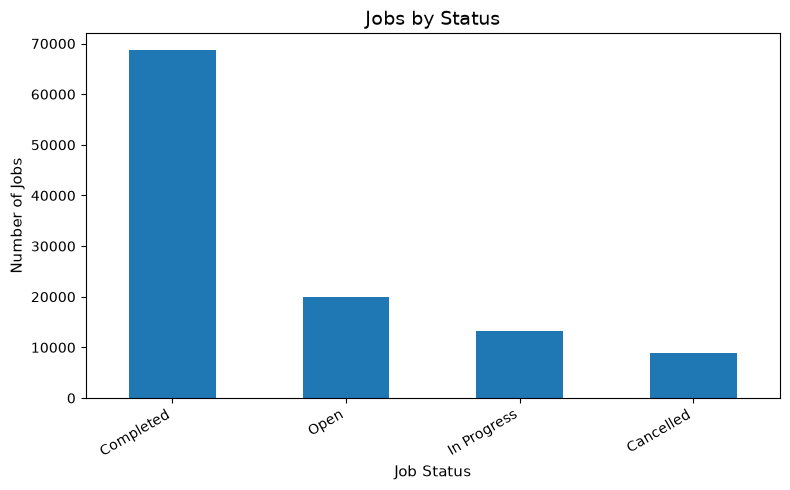

In [35]:
status_counts = clean["Job_Status"].value_counts()

plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("Jobs by Status")
plt.xlabel("Job Status")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 13.4 Monthly Job Posting Trend

This visualization shows how the number of posted freelance jobs changes over time.

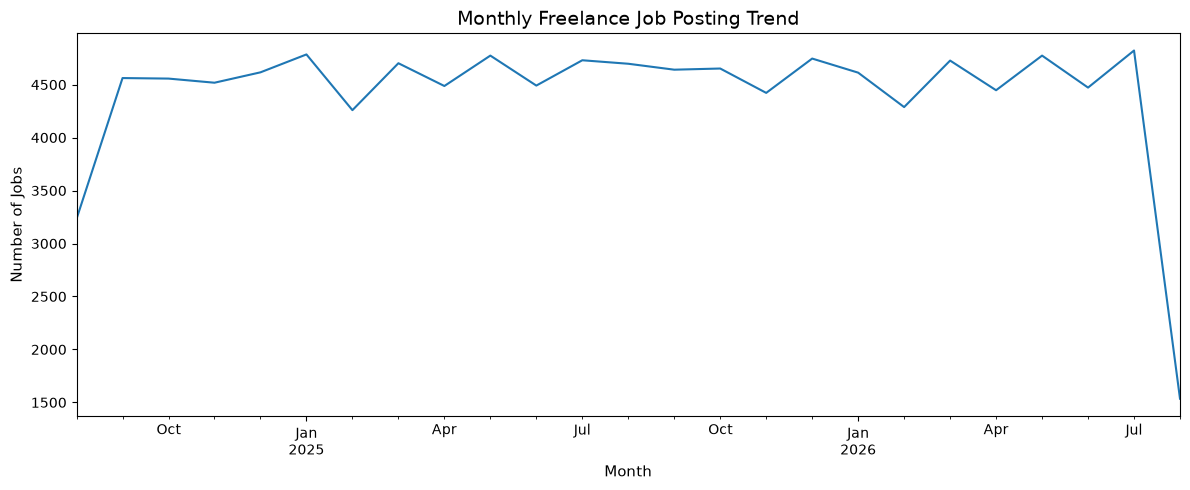

In [36]:
monthly_jobs = (
    clean
    .dropna(subset=["Posted_Date"])
    .set_index("Posted_Date")
    .resample("MS")
    .size()
)

plt.figure(figsize=(12, 5))
monthly_jobs.plot()
plt.title("Monthly Freelance Job Posting Trend")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

## 13.5 Budget Distribution

To make the chart readable, the visualization is limited to the 99th percentile.  
This affects only the chart, not the cleaned dataset.

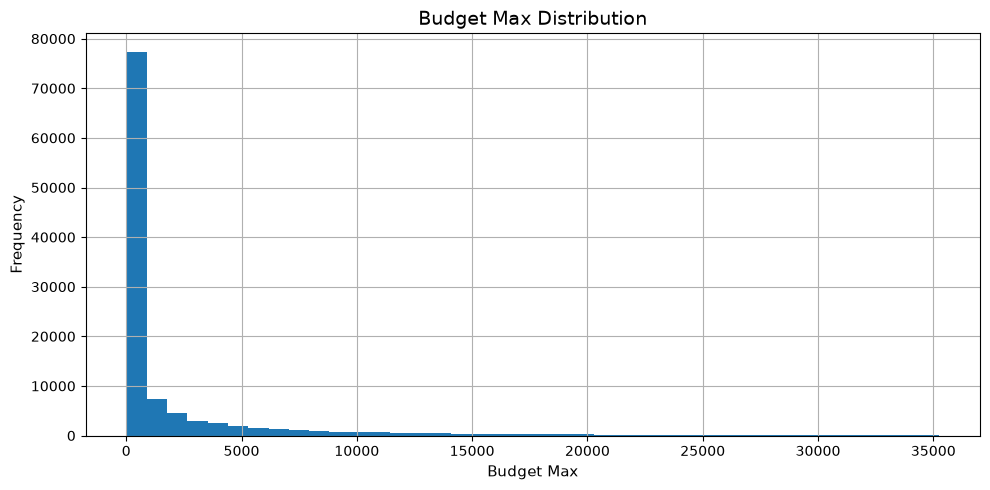

In [37]:
budget_max = pd.to_numeric(clean["Budget_Max"], errors="coerce")

if budget_max.notna().any():
    upper_viz = budget_max.quantile(0.99)

    plt.figure(figsize=(10, 5))
    budget_max[budget_max <= upper_viz].hist(bins=40)
    plt.title("Budget Max Distribution")
    plt.xlabel("Budget Max")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 13.6 Applicants vs Proposals

This scatter plot explores the relationship between the number of applicants and proposals.

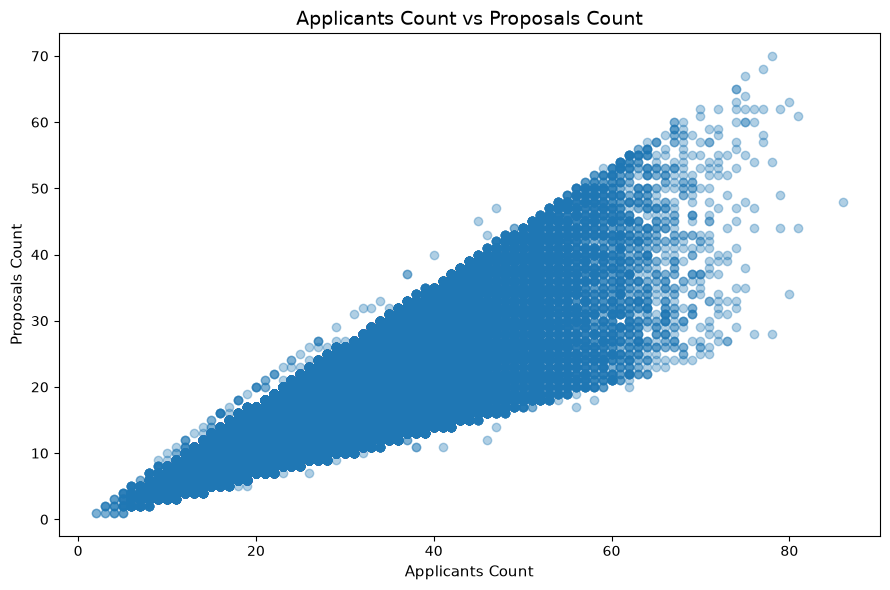

In [38]:
scatter_df = clean[
    ["Applicants_Count", "Proposals_Count"]
].dropna()

plt.figure(figsize=(9, 6))
plt.scatter(
    scatter_df["Applicants_Count"],
    scatter_df["Proposals_Count"],
    alpha=0.35
)
plt.title("Applicants Count vs Proposals Count")
plt.xlabel("Applicants Count")
plt.ylabel("Proposals Count")
plt.tight_layout()
plt.show()

# 14. Key EDA Summary

After running the notebook, summarize the main findings here.

Suggested points to report:

- Number of dirty duplicated records detected and removed.
- Columns with the largest amount of missing data.
- Numeric fields that contained extreme outliers.
- Invalid or inconsistent dates found before cleaning.
- Most common budget type.
- Most common experience level.
- Overall trend in freelance job postings.
- Any notable relationship between applicants and proposals.

> This section is useful in the final project presentation because it turns technical EDA results into clear business observations.

# 15. Final Result

The notebook now provides a complete project-ready pipeline:

**Raw / Dirty Data → Data Understanding → EDA → Data Cleaning → Validation → Clean Dataset → Visualization**

The exported clean file can be used as the trusted source for the next stage of the project.